<div style="
    background: linear-gradient(135deg, #fff0f5, #fff5eb);
    padding: 40px;
    border-radius: 15px;
    text-align: center;
    box-shadow: 0px 10px 25px rgba(0,0,0,0.08);
    border-top: 6px solid #ffccd5;
">

### <span style="color:#e64980;">ARTI308 - Machine Learning</span>

# <span style="color:#c9184a;">Assignment 1: Exploratory Data Analysis (EDA)</span>

#### <span style="color:#7a6c5d;">Perfume Dataset</span>

### <span style="color:#d6336c;">Jana Alwagdani (2220004824)</span>

</div>


# **Task 1: Identify Data Quality Issues**

In [3]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("perfume data.csv")  

# basic shape
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (31275, 23)


,brand,title,note1,note2,note3,note4,note5,note6,note7,note8,...,note12,note13,note14,note15,note16,note17,note18,note19,note20,gender
0,The-Spirit-of-Dubai,Aamal The Spirit of Dubai for women and men,Bulgarian rose,Bergamot,Fruits,Agarwood (oud),Sandalwood,Agarwood (oud),Cypriol oil or nagarmotha,Benzoin,...,Moss,Agarwood (oud),Indian oud,NaN,NaN,NaN,NaN,NaN,NaN,women
1,Ajmal,Aatifa Ajmal for women and men,Rose,Cumin,Amber,Woody notes,Musk,Amber,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,women
2,Al-Jazeera-Perfumes,AA Al-Jazeera Perfumes for women and men,Rose,Sandalwood,Apple,Agarwood (oud),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,women
3,Art-of-Scent-Swiss-Perfumes,aarewasser Art of Scent - Swiss Perfumes for w...,Green tea,White flowers,Ozonic notes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,women
4,Hamidi-Oud-Perfumes,Aaliyah Hamidi Oud & Perfumes for women and men,Amber,Sandalwood,Floral notes,Vetiver,Saffron,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,women


In [4]:
# column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31275 entries, 0 to 31274
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   brand   31275 non-null  object
 1   title   31275 non-null  object
 2   note1   31264 non-null  object
 3   note2   30204 non-null  object
 4   note3   28156 non-null  object
 5   note4   26042 non-null  object
 6   note5   23726 non-null  object
 7   note6   21132 non-null  object
 8   note7   18430 non-null  object
 9   note8   15344 non-null  object
 10  note9   11224 non-null  object
 11  note10  8400 non-null   object
 12  note11  6278 non-null   object
 13  note12  4619 non-null   object
 14  note13  3454 non-null   object
 15  note14  2622 non-null   object
 16  note15  2056 non-null   object
 17  note16  1582 non-null   object
 18  note17  1224 non-null   object
 19  note18  952 non-null    object
 20  note19  742 non-null    object
 21  note20  581 non-null    object
 22  gender  24802 non-null

### Data Overview Analysis

- The dataset contains 31,275 entries and 23 columns.
- All columns are of type object (text data).
- The `brand` and `title` columns have no missing values.

### Missing Values

- Missing values are present in most of the note columns.
- The number of non-null values decreases from `note1` to `note20`.
- `note1` is almost complete, while `note20` has very few values.
- This indicates inconsistency in the number of notes per entry.

### Gender Column

- The `gender` column has missing values (24,802 non-null out of 31,275).

### General Observation

- The dataset consists entirely of textual data.
- The note columns are not uniformly populated across all rows.

In [5]:
# missing values summary
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values(by="Missing Percentage", ascending=False)

missing_df

,Missing Values,Missing Percentage
note20,30694,98.14
note19,30533,97.63
note18,30323,96.96
note17,30051,96.09
note16,29693,94.94
note15,29219,93.43
note14,28653,91.62
note13,27821,88.96
note12,26656,85.23
note11,24997,79.93


### Missing Values Analysis

- Most missing values are in the note columns, especially from `note10` to `note20`.
- `note20` has the highest missing percentage (98.14%), followed by `note19` and `note18`.
- The missing percentage gradually decreases from `note20` to `note1`.
- `note1` is almost complete with only 0.04% missing values.
- This shows that higher-level notes are rarely available in the dataset.

### Gender Column

- The `gender` column has 20.70% missing values, which is relatively significant.

### Complete Columns

- The `brand` and `title` columns have no missing values (0%).

### Overall Observation

- Missing values are mainly concentrated in the note features.
- The dataset is not balanced in terms of note availability across rows.

In [6]:
# duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())

# duplicated titles
print("Number of duplicated titles:", df.duplicated(subset=["title"]).sum())

# duplicated brand-title combinations
print("Number of duplicated brand-title rows:", df.duplicated(subset=["brand", "title"]).sum())

Number of duplicated rows: 113
Number of duplicated titles: 198
Number of duplicated brand-title rows: 192


### Duplicate Values Analysis

- There are 113 fully duplicated rows in the dataset.
- The `title` column has 198 duplicated values.
- There are 192 duplicated combinations of `brand` and `title`.

### Overall Observation

- Some perfumes appear more than once in the dataset.
- This may indicate redundant data that should be handled during preprocessing.

In [7]:
# check unique values in categorical columns
categorical_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique()
})

categorical_summary

,Data Type,Unique Values
brand,object,3123
title,object,31077
note1,object,919
note2,object,929
note3,object,882
note4,object,842
note5,object,798
note6,object,753
note7,object,693
note8,object,651


### Unique Values Analysis

- The `brand` column has 3123 unique values, indicating high diversity.
- The `title` column has 31,077 unique values, meaning most entries are unique.

### Notes Columns

- The note columns (`note1` to `note20`) have a decreasing number of unique values.
- `note1` has the highest diversity (919 unique values), while `note20` has the lowest (125).
- This suggests that earlier notes are more varied than later ones.

### Gender Column

- The `gender` column has only 3 unique values.
- This indicates it is a low-cardinality categorical feature.

### Overall Observation

- Some columns (like brand and title) have high cardinality.
- Note features show decreasing diversity as the note number increases.

In [8]:
# check gender values
print(df["gender"].value_counts(dropna=False))

gender
women     24224
NaN        6473
man         524
unisex       54
Name: count, dtype: int64


### Gender Distribution Analysis

- The majority of the data belongs to `women` (24,224 entries).
- There are 6,473 missing values in the `gender` column.
- The `man` category has only 524 entries.
- The `unisex` category is very small with only 54 entries.

### Overall Observation

- The dataset is highly imbalanced toward the `women` category.
- Some gender values are missing, which may affect analysis or modeling.

In [9]:
# check leading/trailing spaces in text columns
text_cols = df.select_dtypes(include="object").columns

whitespace_issues = {
    col: ((df[col].dropna().astype(str) != df[col].dropna().astype(str).str.strip()) |
          (df[col].dropna().astype(str).str.contains(r"\s{2,}", regex=True))).sum()
    for col in text_cols
}

whitespace_df = pd.DataFrame.from_dict(whitespace_issues, orient="index", columns=["Whitespace Issues"])
whitespace_df = whitespace_df[whitespace_df["Whitespace Issues"] > 0].sort_values(by="Whitespace Issues", ascending=False)

whitespace_df

,Whitespace Issues
title,384
note4,2
note5,2
note7,2
note12,2
note8,1
note10,1


### Whitespace Issues Analysis

- The `title` column has the highest number of whitespace issues (384 cases).
- Minor whitespace issues are also found in some note columns such as `note4`, `note5`, `note7`, `note12`, `note8`, and `note10`.

### Overall Observation

- Most whitespace problems are concentrated in the `title` column.
- These issues may affect text consistency and should be cleaned during preprocessing.

In [10]:
# check repeated notes inside the same row
note_cols = [col for col in df.columns if col.startswith("note")]

def has_duplicate_notes(row):
    values = [str(v).strip().lower() for v in row if pd.notna(v)]
    return len(values) != len(set(values))

duplicate_notes_rows = df[note_cols].apply(has_duplicate_notes, axis=1).sum()
print("Rows with duplicated notes inside the same perfume:", duplicate_notes_rows)

Rows with duplicated notes inside the same perfume: 760


### Duplicated Notes Analysis

- There are 760 rows where the same note appears more than once within the same perfume.

### Overall Observation

- Some perfumes contain repeated notes, which may indicate data redundancy.
- This issue should be handled during data cleaning.

In [11]:
# final summary table for Task 1
issues_summary = pd.DataFrame({
    "Issue": [
        "Missing values",
        "Duplicated rows",
        "Duplicated titles",
        "Duplicated brand-title rows",
        "Whitespace issues in text columns",
        "Inconsistent gender labels",
        "Repeated notes in same row"
    ],
    "Result": [
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(df.duplicated(subset=["title"]).sum()),
        int(df.duplicated(subset=["brand", "title"]).sum()),
        int(sum(whitespace_df["Whitespace Issues"])) if not whitespace_df.empty else 0,
        df["gender"].dropna().unique().tolist(),
        int(duplicate_notes_rows)
    ]
})

issues_summary

,Issue,Result
0,Missing values,393941
1,Duplicated rows,113
2,Duplicated titles,198
3,Duplicated brand-title rows,192
4,Whitespace issues in text columns,394
5,Inconsistent gender labels,"[women, man, unisex]"
6,Repeated notes in same row,760


### Data Quality Issues Summary

- The dataset contains a large number of missing values (393,941), mainly in note columns.
- There are 113 duplicated rows in the dataset.
- The `title` column has 198 duplicated values.
- There are 192 duplicated `brand-title` combinations.
- A total of 394 whitespace issues were found in text columns, mostly in `title`.
- The `gender` column includes three categories: women, man, and unisex.
- There are 760 rows with repeated notes within the same perfume.

### Overall Conclusion

- The dataset has several data quality issues, including missing values, duplicates, and text inconsistencies.
- Data cleaning is required before performing further analysis or modeling.


# **Task 2 Apply one missing value strategy and explain why**

In [15]:
df["gender"] = df["gender"].fillna("Unknown")
df["gender"].value_counts()

gender
women      24224
Unknown     6473
man          524
unisex        54
Name: count, dtype: int64

### Missing Value Strategy for Gender

- Missing values in the `gender` column were replaced with a new category called "Unknown".
- This strategy was used because `gender` is a categorical feature, and mean or median imputation are not applicable.
- Removing records was not preferred because the column contains a relatively high number of missing values (about 20%).
- Using mode was avoided to prevent introducing bias toward the majority class (women).
- Therefore, assigning "Unknown" helps preserve the dataset while maintaining data integrity.

In [16]:
df_cleaned = df.dropna(subset=["note1"])
print("Original shape:", df.shape)
print("New shape after removing missing note1:", df_cleaned.shape)

Original shape: (31275, 23)
New shape after removing missing note1: (31264, 23)


### Missing Value Strategy

- Strategy 1 (Remove Records) was applied to the `note1` column.
- This column was selected because it contains a very small number of missing values.
- Removing these records does not significantly affect the dataset size.
- This approach ensures data quality without losing a large portion of the data.

# **Task 3 Detect and handle outliers using IQR**

In [18]:
# count number of notes per row
note_cols = [col for col in df.columns if col.startswith("note")]

df["num_notes"] = df[note_cols].notna().sum(axis=1)

df["num_notes"].describe()

count    31275.000000
mean         7.610935
std          4.104817
min          1.000000
25%          5.000000
50%          7.000000
75%         10.000000
max         20.000000
Name: num_notes, dtype: float64

In [19]:
# calculate IQR
Q1 = df["num_notes"].quantile(0.25)
Q3 = df["num_notes"].quantile(0.75)
IQR = Q3 - Q1

# bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -2.5
Upper bound: 17.5


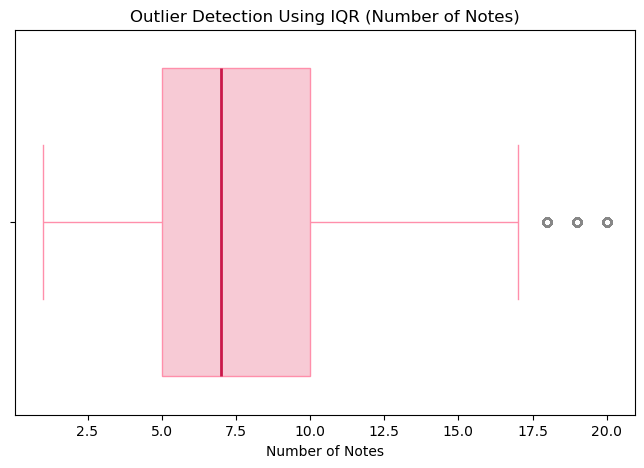

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["num_notes"],
    color="#ffc2d1", 
    boxprops=dict(edgecolor="#ff8fab"),
    whiskerprops=dict(color="#ff8fab"),
    capprops=dict(color="#ff8fab"),
    medianprops=dict(color="#c9184a", linewidth=2)
)

plt.title("Outlier Detection Using IQR (Number of Notes)")
plt.xlabel("Number of Notes")

plt.show()

In [20]:
outliers = df[(df["num_notes"] < lower_bound) | (df["num_notes"] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 952


In [21]:
# remove outliers
df_no_outliers = df[(df["num_notes"] >= lower_bound) & (df["num_notes"] <= upper_bound)]

print("Shape after removing outliers:", df_no_outliers.shape)

Shape after removing outliers: (30323, 24)


### Outlier Detection using IQR

- Since the dataset does not contain numerical features, a new feature called `num_notes` was created to represent the number of notes in each perfume.
- The IQR method was applied to detect outliers based on this feature.

### Results

- Q1 and Q3 were calculated to determine the interquartile range (IQR).
- Lower and upper bounds were defined using the IQR formula.
- Rows with unusually low or high numbers of notes were identified as outliers.

### Handling Outliers

- Detected outliers were removed from the dataset.
- This helps improve data consistency and reduces noise in the analysis.

# **Task 4 Normalize numerical features using both Min-Max and Z-score.**

In [26]:
# Min-Max Scaling
df["num_notes_minmax"] = (df["num_notes"] - df["num_notes"].min()) / (df["num_notes"].max() - df["num_notes"].min())

df[["num_notes", "num_notes_minmax"]].head()

,num_notes,num_notes_minmax
0,14,0.684211
1,6,0.263158
2,4,0.157895
3,3,0.105263
4,5,0.210526


In [27]:
# Z-score Scaling
df["num_notes_zscore"] = (df["num_notes"] - df["num_notes"].mean()) / df["num_notes"].std()

df[["num_notes", "num_notes_zscore"]].head()

,num_notes,num_notes_zscore
0,14,1.556480
1,6,-0.392450
2,4,-0.879682
3,3,-1.123299
4,5,-0.636066


### Feature Normalization

- A numerical feature `num_notes` was normalized using two methods: Min-Max and Z-score.

### Min-Max Normalization

- This method scales values between 0 and 1.
- It preserves the relative differences between values.

### Z-score Normalization

- This method standardizes the data using mean and standard deviation.
- It transforms the data to have a mean of 0 and standard deviation of 1.

### Overall Observation

- Min-Max is useful when the data needs to be within a fixed range.
- Z-score is useful when handling outliers and standardizing distributions.

# **Task 5 Apply PCA only if the numerical features show a correlation**

### PCA Application

- PCA (Principal Component Analysis) was not applied in this dataset.
- This is because the dataset contains only one numerical feature (`num_notes`).
- PCA requires multiple numerical features to analyze correlations and reduce dimensionality.
- Since no correlation can be computed with a single feature, PCA is not applicable in this case.

### Feature Engineering

- New numerical features were created from the dataset to enable further analysis.
- These features include:
  - Number of notes (`num_notes`)
  - Length of perfume title (`title_length`)
  - Word count of title (`title_word_count`)
  - Number of unique notes (`unique_notes`)
- These features allow correlation analysis and make PCA applicable.

In [28]:
df["title_length"] = df["title"].apply(len)

In [29]:
df["title_word_count"] = df["title"].apply(lambda x: len(str(x).split()))

In [30]:
note_cols = [col for col in df.columns if col.startswith("note")]

df["unique_notes"] = df[note_cols].apply(
    lambda row: len(set([str(v).lower().strip() for v in row if pd.notna(v)])), axis=1
)

In [31]:
df["is_complex"] = df["num_notes"].apply(lambda x: 1 if x > 5 else 0)

In [32]:
df[["num_notes", "title_length", "title_word_count", "unique_notes"]].corr()

,num_notes,title_length,title_word_count,unique_notes
num_notes,1.000000,-0.065176,-0.065843,0.998754
title_length,-0.065176,1.000000,0.901741,-0.065400
title_word_count,-0.065843,0.901741,1.000000,-0.066341
unique_notes,0.998754,-0.065400,-0.066341,1.000000


### Correlation Analysis

- A correlation matrix was computed for the numerical features.
- There is a very strong positive correlation between `num_notes` and `unique_notes` (0.998).
- There is also a strong correlation between `title_length` and `title_word_count` (0.90).
- Other correlations are weak or close to zero.


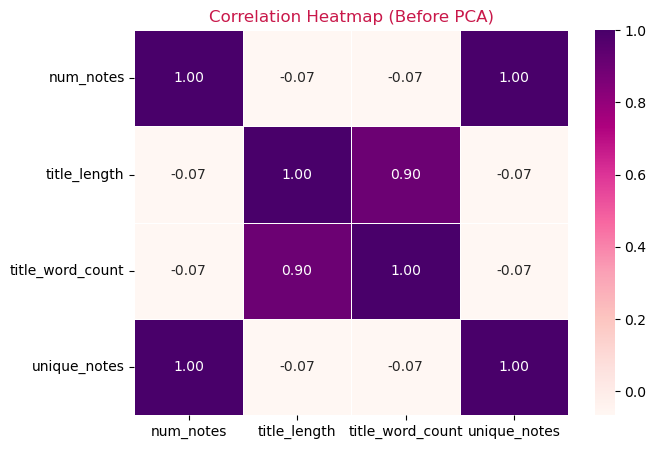

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["num_notes", "title_length", "title_word_count", "unique_notes"]

plt.figure(figsize=(7,5))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="RdPu", 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Before PCA)", color="#c9184a")

plt.show()

### Correlation Heatmap (Before PCA)

- A heatmap was used to visualize the correlation between numerical features before applying PCA.
- Strong positive correlations can be observed between `num_notes` and `unique_notes`.
- There is also a high correlation between `title_length` and `title_word_count`.
- Other correlations are relatively weak.


In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ["num_notes", "title_length", "title_word_count", "unique_notes"]

# scaling first 
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# add to dataframe
df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.52257404 0.45254984]


### PCA Application

- PCA was applied because strong correlations were found between some numerical features.
- The features were first standardized using Z-score normalization.
- PCA reduced the features into 2 principal components.
- This helps remove redundancy and simplify the dataset while preserving important information.

### PCA Results

- The first principal component (PCA1) explains 52.26% of the variance.
- The second principal component (PCA2) explains 45.25% of the variance.

### Overall Observation

- Together, the two components explain around 97.5% of the total variance.
- This means most of the information in the original features is preserved.
- PCA was effective in reducing dimensionality while keeping important patterns in the data.

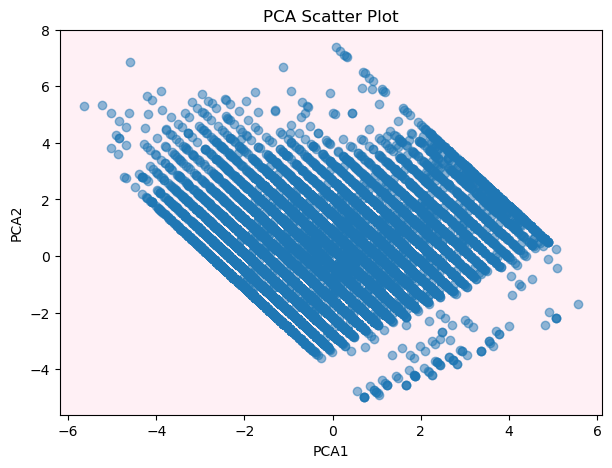

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    df["PCA1"], 
    df["PCA2"], 
    alpha=0.5
)


plt.title("PCA Scatter Plot")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.gca().set_facecolor("#fff0f5") 

plt.show()

### PCA Visualization Analysis

- The scatter plot shows the distribution of data using the two principal components (PCA1 and PCA2).
- Most data points are densely clustered in a diagonal pattern, indicating strong relationships between the features.
- This pattern reflects the high correlation observed earlier between some features.
- A few points appear farther from the main cluster, which may represent outliers or less common patterns.

### Overall Observation

- The data structure is preserved after applying PCA.
- The diagonal shape suggests that some features carry similar information.
- PCA successfully reduced the dimensionality while maintaining most of the variance in the data.